# Burgers 1D Force Identification

**PDE**: $u_t + u \, u_x - \nu u_{xx} = s(x)$ on $x \in [0, 2\pi)$ with periodic boundary conditions and $t \in [0, T]$.

**True force**: $s_{\mathrm{true}}(x) = \sin(2x)$.

This notebook imports the Burgers solver stack, runs optional spatial and temporal convergence checks, generates terminal data, verifies adjoint gradients, solves the inverse problem with both an adjoint neural-network parameterization and a coarse-force direct adjoint baseline, trains a PINN baseline, and compares the recovered forces and terminal states.

| Method | Approach |
|--------|----------|
| **Adjoint NN** | Crank-Nicolson forward solver, exact discrete adjoint, neural-network force parameterization, SSBroyden2 BFGS |
| **Adjoint coarse force** | Discrete adjoint on a coarse force mesh interpolated to the fine grid, SSBroyden2 BFGS |
| **PINN (direct residual)** | Joint $U_\theta(x,t)$ and $S_\phi(x)$, Adam warmup + SSBroyden2 BFGS |

## 1. Import Dependencies and Configure the Burgers Setup

Set the working directory, import the solver utilities, and instantiate the baseline Burgers configuration used throughout the notebook.

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import torch
torch.set_default_dtype(torch.float64)

new_dir = "/users/zzhan536/myData/playing_center/adjoint_test/Burgers_identification"
os.chdir(new_dir)
sys.path.insert(0, new_dir)
print(f"Working directory: {os.getcwd()}")

from cfg import BurgersConfig
from solver import (
    BurgersFDCore, burgers_forward, initial_condition, true_force,
    rel_l2_error, test_convergence,
)

cfg = BurgersConfig()
print(f"Device: {cfg.device}")
print(f"N={cfg.N}, dt={cfg.dt}, nu={cfg.nu}, T={cfg.t_final}")

Working directory: /oscar/data/gk/zzhan536/playing_center/adjoint_test/Burgers_identification
Device: cuda
N=512, dt=0.01, nu=0.015, T=1.0


## 2. Optional Solver Convergence Checks

These two disabled cells contain spatial and temporal convergence studies for the Crank-Nicolson Burgers solver.

In [ ]:
if False:
    results = test_convergence(N_min=32, level=6, Cdt=1, t_final=cfg.t_final)

    # Plot convergence
    Ns   = [r[0] for r in results]
    dxs  = [r[1] for r in results]
    rels = [r[3] for r in results]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.loglog(dxs, rels, 'bo-', label='Relative $L^2$')
    # reference slope
    dxs_arr = np.array(dxs)
    ax.loglog(dxs_arr, rels[0] * (dxs_arr / dxs_arr[0])**2, 'k--', label='$O(\Delta x^2)$')
    ax.set_xlabel('$\Delta x$'); ax.set_ylabel('Relative $L^2$ error')
    ax.set_title('Spatial Convergence (Burgers, CN)')
    ax.legend(); ax.grid(True, ls=':')
    fig.tight_layout()
    fig.savefig('figures/convergence.png', bbox_inches='tight')
    plt.show()
    """ 
    N	 dx		 dt		 relL2		 relLinf
    32	 1.96350e-01	 1.96350e-01	 1.33333e-02	 2.52275e-02
    64	 9.81748e-02	 9.81748e-02	 3.50970e-03	 8.13172e-03
    128	 4.90874e-02	 4.90874e-02	 8.76479e-04	 2.08213e-03
    256	 2.45437e-02	 2.45437e-02	 2.09916e-04	 5.07302e-04
    512	 1.22718e-02	 1.22718e-02	 4.19452e-05	 1.01438e-04

    Estimated order (from relative L2):
    N=32 -> N=64: p ~ 1.93
    N=64 -> N=128: p ~ 2.00
    N=128 -> N=256: p ~ 2.06
    N=256 -> N=512: p ~ 2.32
    """

In [ ]:
if False:
    # Temporal convergence test at N=512 (fixed spatial grid)
    from solver import BurgersConfig as _BC

    N_test = 512
    L = 2 * np.pi
    nu = 0.015
    t_final = cfg.t_final

    dts = [0.04, 0.02, 0.01, 0.005, 0.0025]

    # Reference with very fine dt
    dt_ref = dts[-1] / 4
    cfg_ref = _BC(N=N_test, dt=dt_ref, t_final=t_final, nu=nu)
    x_test = np.linspace(0, L, N_test, endpoint=False)
    u0_test = initial_condition(x_test)
    s_test = true_force(x_test)
    out_ref = burgers_forward(u0_test, s_test, cfg_ref)
    u_ref = out_ref["u_final"]

    results_dt = []
    for dt_i in dts:
        cfg_i = _BC(N=N_test, dt=dt_i, t_final=t_final, nu=nu)
        out_i = burgers_forward(u0_test, s_test, cfg_i)
        u_i = out_i["u_final"]
        err = rel_l2_error(u_i, u_ref)
        results_dt.append((dt_i, err))
        print(f"dt={dt_i:.4e}  rel_L2={err:.4e}")

    print("\nEstimated temporal order:")
    for k in range(len(results_dt) - 1):
        dt1, e1 = results_dt[k]
        dt2, e2 = results_dt[k + 1]
        if e2 > 0:
            p = np.log(e1 / e2) / np.log(dt1 / dt2)
            print(f"  dt={dt1:.4e} -> dt={dt2:.4e}: p ~ {p:.2f}")

    # Plot
    fig, ax = plt.subplots(figsize=(6, 4))
    dts_arr = np.array([r[0] for r in results_dt])
    errs_arr = np.array([r[1] for r in results_dt])
    ax.loglog(dts_arr, errs_arr, 'rs-', label='Relative $L^2$')
    ax.loglog(dts_arr, errs_arr[0] * (dts_arr / dts_arr[0])**2, 'k--', label='$O(\Delta t^2)$')
    ax.set_xlabel('$\Delta t$'); ax.set_ylabel('Relative $L^2$ error')
    ax.set_title(f'Temporal Convergence (Burgers CN, N={N_test})')
    ax.legend(); ax.grid(True, ls=':')
    fig.tight_layout()
    fig.savefig('figures/temporal_convergence.png', bbox_inches='tight')
    plt.show()

    """ 
    dt=4.0000e-02  rel_L2=2.0277e-04
    dt=2.0000e-02  rel_L2=5.0782e-05
    dt=1.0000e-02  rel_L2=1.2665e-05
    dt=5.0000e-03  rel_L2=3.1296e-06
    dt=2.5000e-03  rel_L2=7.4520e-07

    Estimated temporal order:
    dt=4.0000e-02 -> dt=2.0000e-02: p ~ 2.00
    dt=2.0000e-02 -> dt=1.0000e-02: p ~ 2.00
    dt=1.0000e-02 -> dt=5.0000e-03: p ~ 2.02
    dt=5.0000e-03 -> dt=2.5000e-03: p ~ 2.07
    """

## 3. Generate Reference Data

Solve the forward Burgers problem with the true forcing, visualize the reference trajectory, and time one adjoint objective-and-gradient evaluation.

Reference trajectory: shape = (101, 512)
Time steps: 101, t in [0.00, 1.00]


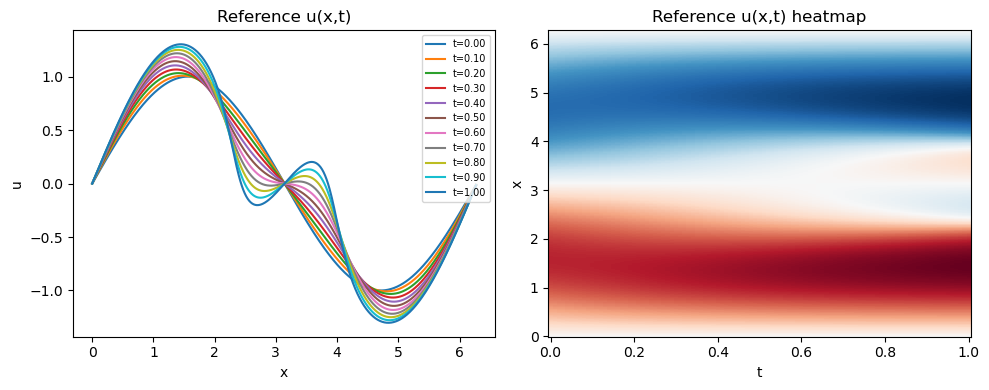


Objective + gradient: 1.9471 s
  loss = 3.524980e+00, |grad| = 2.959e+01, #params = 1153


In [5]:
import time
from adjoint_operator import BurgersAdjointNN, get_init_phi

core = BurgersFDCore(cfg)
x = core.x
u0 = initial_condition(x)
s_true = true_force(x)

# Forward solve with true force
fwd = core.forward(u0, s_true, store_trajectory=True)
U_hist = fwd["U_hist"]
uT_target = fwd["u_final"].copy()
t_hist = np.linspace(0, cfg.t_final, core.Nt + 1)

print(f"Reference trajectory: shape = {U_hist.shape}")
print(f"Time steps: {len(t_hist)}, t in [{t_hist[0]:.2f}, {t_hist[-1]:.2f}]")

# Plot reference solution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes[0]
n_plot = min(10, U_hist.shape[0])
stride = max(1, U_hist.shape[0] // n_plot)
for k in range(0, U_hist.shape[0], stride):
    ax.plot(x, U_hist[k, :], label=f't={t_hist[k]:.2f}')
ax.set_xlabel('x'); ax.set_ylabel('u')
ax.set_title('Reference u(x,t)'); ax.legend(fontsize=7)

ax = axes[1]
ax.pcolormesh(t_hist, x, U_hist.T, shading='auto', cmap='RdBu_r')
ax.set_xlabel('t'); ax.set_ylabel('x')
ax.set_title('Reference u(x,t) heatmap')
fig.tight_layout()
fig.savefig('figures/reference_solution.png', bbox_inches='tight')
plt.show()

# Time forward + adjoint pass
phi0 = get_init_phi(cfg)
adj = BurgersAdjointNN(cfg)

t0_t = time.perf_counter()
loss, grad = adj.scipy_objective(phi0, u0, uT_target)
t1_t = time.perf_counter()
print(f"\nObjective + gradient: {t1_t - t0_t:.4f} s")
print(f"  loss = {loss:.6e}, |grad| = {np.linalg.norm(grad):.3e}, #params = {len(phi0)}")

## 4. Verify the Adjoint Gradient

Run a finite-difference gradient check on a smaller Burgers configuration before the full inverse solve.

In [6]:
from adjoint_operator import get_init_phi, gradient_check

# Use a small grid for fast gradient check
cfg_gc = BurgersConfig(N=64, dt=0.05, t_final=0.5)
core_gc = BurgersFDCore(cfg_gc)
x_gc = core_gc.x
u0_gc = initial_condition(x_gc)
s_gc = true_force(x_gc)
uT_gc = burgers_forward(u0_gc, s_gc, cfg_gc)["u_final"]

phi_gc = get_init_phi(cfg_gc)
print(f"NN parameter count: {len(phi_gc)}")

results_gc = gradient_check(cfg_gc, u0_gc, uT_gc, phi_gc, n_checks=15, eps_fd=1e-5)

max_err = max(r['rel_err'] for r in results_gc)
print(f"\nGradient check PASSED" if max_err < 1e-3 else f"\nWARNING: max rel err = {max_err:.2e}")

NN parameter count: 1153
  idx        FD grad       Adj grad      rel err
  101   8.787025e-02   8.787025e-02   2.0417e-11
  108  -8.407970e-02  -8.407970e-02   6.9577e-11
  746   1.073376e-01   1.073376e-01   4.7351e-11
  876  -7.595336e-03  -7.595336e-03   2.9333e-10
  231  -5.565509e-03  -5.565509e-03   1.9197e-10
  827  -1.066983e-01  -1.066983e-01   5.2701e-11
   98  -1.111166e-02  -1.111166e-02   1.5266e-10
  846  -3.368507e-02  -3.368507e-02   6.0936e-11
  501  -1.004335e-02  -1.004335e-02   6.2411e-10
  982  -2.636350e-02  -2.636350e-02   3.0459e-11
  494   4.084559e-02   4.084559e-02   2.3484e-11
  604  -3.663570e-02  -3.663570e-02   1.2111e-10
  882  -7.884624e-03  -7.884624e-03   4.3761e-10
  799  -4.874665e-03  -4.874665e-03   1.2856e-09
 1121  -1.600746e-01  -1.600746e-01   2.4566e-11

Max relative error: 1.2856e-09

Gradient check PASSED


## 5. Run Adjoint-Based Force Identification

First optimize the neural-network force parameterization with the discrete adjoint, then build and optimize a coarse-force direct adjoint baseline on the fine spatial grid.

In [7]:
from adjoint_operator import invert_force_adjoint, simulate_with_phi

phi0 = get_init_phi(cfg)

phi_opt, adj_history = invert_force_adjoint(
    u0, uT_target, cfg, phi0,
    n_steps_warmup=0,
)

Starting BFGS optimization...
  iter 0000: loss=1.346066e+00 |g|=1.444e+00 rel_uT=7.877e-01 rel_f=9.916e-01
  iter 0010: loss=9.836369e-01 |g|=8.254e-01 rel_uT=6.733e-01 rel_f=9.158e-01
  iter 0020: loss=3.954305e-01 |g|=4.883e+00 rel_uT=4.269e-01 rel_f=6.657e-01
  iter 0030: loss=1.567907e-01 |g|=1.633e+00 rel_uT=2.688e-01 rel_f=4.852e-01
  iter 0040: loss=1.012146e-01 |g|=1.320e+00 rel_uT=2.160e-01 rel_f=3.849e-01
  iter 0050: loss=6.674381e-02 |g|=9.686e-01 rel_uT=1.754e-01 rel_f=3.686e-01
  iter 0060: loss=3.867882e-02 |g|=2.305e+00 rel_uT=1.335e-01 rel_f=3.170e-01
  iter 0070: loss=6.271506e-03 |g|=2.199e+00 rel_uT=5.376e-02 rel_f=1.622e-01
  iter 0080: loss=1.065185e-03 |g|=9.133e-01 rel_uT=2.216e-02 rel_f=1.073e-01
  iter 0090: loss=3.029430e-04 |g|=1.612e-01 rel_uT=1.182e-02 rel_f=1.020e-01
  iter 0100: loss=1.170815e-04 |g|=2.688e-01 rel_uT=7.346e-03 rel_f=3.827e-02
  iter 0110: loss=5.649558e-05 |g|=2.579e-02 rel_uT=5.103e-03 rel_f=2.830e-02
  iter 0120: loss=1.518421e-05 |g|

In [7]:
# Direct adjoint on coarse force mesh N_f=64, fine spatial grid N=512
# Force is N_f=64 nodal values, linearly interpolated to fine grid.
# Gradient w.r.t. coarse force: P^T @ (adjoint gradient w.r.t. fine force).

N_f = 64

def build_interp_matrix(x_fine, L, N_f):
    """Linear periodic interpolation matrix P of shape (N_fine, N_f). s_fine = P @ s_coarse."""
    N = len(x_fine)
    dx_c = L / N_f
    P = np.zeros((N, N_f))
    for i, xf in enumerate(x_fine):
        j = int(xf / dx_c) % N_f
        j1 = (j + 1) % N_f
        xl = j * dx_c
        w1 = (xf - xl) / dx_c
        w0 = 1.0 - w1
        P[i, j] += w0
        P[i, j1] += w1
    return P

def adjoint_objective_coarse(s_coarse, P, core, u0_fine, uT_target_fine):
    """J = 0.5*dx*||u(T)-uT_target||^2 and gradient dJ/ds_coarse via discrete adjoint."""
    dt, dx, Nt, N = core.dt, core.dx, core.Nt, core.N
    s_fine = P @ s_coarse
    fwd = core.forward(u0_fine, s_fine, store_trajectory=True)
    uT = fwd["u_final"]
    U_hist = fwd["U_hist"]
    mis = uT - uT_target_fine
    loss = 0.5 * dx * np.dot(mis, mis)

    D, Lx, nu_val = core.D, core.Lx, core.nu
    I = np.eye(N)
    A_list, B_list = [], []
    for n in range(Nt):
        Jfn  = -np.diag(D @ U_hist[n])   - np.diag(U_hist[n])   @ D + nu_val * Lx
        Jfn1 = -np.diag(D @ U_hist[n+1]) - np.diag(U_hist[n+1]) @ D + nu_val * Lx
        A_list.append(-I - 0.5 * dt * Jfn)
        B_list.append( I - 0.5 * dt * Jfn1)

    dJ_duT = dx * mis
    lam = [None] * (Nt + 1)
    lam[Nt] = np.linalg.solve(B_list[-1].T, -dJ_duT)
    for n in range(Nt - 1, 0, -1):
        lam[n] = np.linalg.solve(B_list[n-1].T, -A_list[n].T @ lam[n+1])
    lam[0] = np.linalg.solve(B_list[0].T, -A_list[0].T @ lam[1])

    lam_sum = sum(lam[n+1] for n in range(Nt))
    grad_s_coarse = P.T @ (-dt * lam_sum)
    return loss, grad_s_coarse

# Build interpolation matrix; reuse u0, uT_target, core (cfg with N=512)
P = build_interp_matrix(core.x, cfg.L, N_f)
x_coarse_f = np.linspace(0, cfg.L, N_f, endpoint=False)
s_true_coarse = true_force(x_coarse_f)
s0_coarse = np.zeros(N_f)

# ── Gradient check ────────────────────────────────────────────
print("=== Gradient check (direct adjoint, coarse force N_f=64, spatial N=512) ===")
loss0, grad0 = adjoint_objective_coarse(s0_coarse, P, core, u0, uT_target)
rng_gc = np.random.default_rng(0)
idx_gc = rng_gc.choice(N_f, size=10, replace=False)
eps_fd = 1e-5
print(f"{'idx':>5s} {'FD grad':>14s} {'Adj grad':>14s} {'rel err':>12s}")
max_rel_err = 0.0
for i in idx_gc:
    sp = s0_coarse.copy(); sp[i] += eps_fd
    sm = s0_coarse.copy(); sm[i] -= eps_fd
    fp, _ = adjoint_objective_coarse(sp, P, core, u0, uT_target)
    fm, _ = adjoint_objective_coarse(sm, P, core, u0, uT_target)
    fd = (fp - fm) / (2 * eps_fd)
    adj_val = grad0[i]
    rel_err = abs(fd - adj_val) / (abs(adj_val) + 1e-30)
    max_rel_err = max(max_rel_err, rel_err)
    print(f"{i:5d} {fd:14.6e} {adj_val:14.6e} {rel_err:12.4e}")
print(f"\nMax relative error: {max_rel_err:.4e}")
print("Gradient check PASSED" if max_rel_err < 1e-3 else f"WARNING: max rel err = {max_rel_err:.2e}")

=== Gradient check (direct adjoint, coarse force N_f=64, spatial N=512) ===
  idx        FD grad       Adj grad      rel err
   46  -4.355173e-02  -4.355173e-02   4.7499e-09
   52   4.473759e-02   4.473760e-02   5.2689e-09
   35  -4.847745e-02  -4.847745e-02   1.2154e-09
   29   4.847745e-02   4.847745e-02   9.8634e-10
   15  -5.434692e-03  -5.434692e-03   4.5872e-08
    2  -2.238583e-02  -2.238583e-02   1.2937e-10
    1  -1.139029e-02  -1.139029e-02   8.8039e-10
   18   4.355173e-02   4.355173e-02   4.4950e-09
   11  -5.277665e-02  -5.277665e-02   4.2127e-09
    4  -4.170038e-02  -4.170038e-02   7.6586e-10

Max relative error: 4.5872e-08
Gradient check PASSED


In [8]:
import time as _time
from scipy.optimize import minimize

# ── BFGS Optimization ─────────────────────────────────────────
print("=== Adjoint optimization (direct coarse force N_f=64, spatial N=512) ===")

coarse_history = {"evals": [], "iters": []}
_last = {}

def _obj(s_c):
    loss, grad = adjoint_objective_coarse(s_c, P, core, u0, uT_target)
    s_fine_pred = P @ s_c
    rel_f = float(rel_l2_error(s_fine_pred, s_true))
    k = len(coarse_history["evals"])
    coarse_history["evals"].append({"k": k, "loss": float(loss), "rel_f": rel_f})
    _last.update({"loss": float(loss), "grad_norm": float(np.linalg.norm(grad)), "rel_f": rel_f})
    return loss, grad

def _cb(s_c):
    k = len(coarse_history["iters"])
    coarse_history["iters"].append({"k": k, **_last})
    if k % 20 == 0:
        print(f"  iter {k:04d}: loss={_last['loss']:.6e} |g|={_last['grad_norm']:.3e} rel_f={_last['rel_f']:.3e}")

t0_c = _time.perf_counter()
res_c = minimize(
    fun=_obj, x0=s0_coarse, jac=True, method="BFGS",
    callback=_cb, tol=0,
    options=dict(maxiter=60, gtol=0.0, disp=False,
                 method_bfgs="SSBroyden2",
                 hess_inv0=np.eye(N_f), initial_scale=False),
)
t1_c = _time.perf_counter()

s_opt_coarse = res_c.x
s_opt_fine = P @ s_opt_coarse

final_loss_c, _ = adjoint_objective_coarse(s_opt_coarse, P, core, u0, uT_target)
final_rel_err_c = float(rel_l2_error(s_opt_fine, s_true))

print(f"\n[Coarse N_f=64, spatial N=512] Runtime          : {t1_c - t0_c:.1f}s")
print(f"[Coarse N_f=64, spatial N=512] Final objective  : {final_loss_c:.6e}")
print(f"[Coarse N_f=64, spatial N=512] Rel L2 error (s) : {final_rel_err_c:.6e}")

=== Adjoint optimization (direct coarse force N_f=64, spatial N=512) ===
  iter 0000: loss=4.942488e-01 |g|=2.860e-01 rel_f=6.203e-01
  iter 0020: loss=1.819764e-07 |g|=7.491e-05 rel_f=3.584e-03
  iter 0040: loss=7.357508e-10 |g|=9.686e-07 rel_f=1.550e-03

[Coarse N_f=64, spatial N=512] Runtime          : 113.3s
[Coarse N_f=64, spatial N=512] Final objective  : 7.068564e-10
[Coarse N_f=64, spatial N=512] Rel L2 error (s) : 1.549444e-03


## 6. Train the PINN Baseline

Train the direct-residual PINN baseline against the same initial condition and terminal target data.

In [4]:
from PINN import train_pinn

pinn_history = train_pinn(u0, uT_target, cfg)

[Adam    1/1000] loss=4.078e+00 res=2.96e+00 ic=4.21e-01 bc=4.67e-02 data=6.48e-01 rel_uT=9.461e-01 rel_f=2.372e+00
[Adam  200/1000] loss=3.523e-01 res=3.92e-02 ic=9.90e-02 bc=2.14e-02 data=1.93e-01 rel_uT=5.264e-01 rel_f=9.826e-01
[Adam  400/1000] loss=3.054e-01 res=5.83e-02 ic=7.43e-02 bc=1.11e-02 data=1.62e-01 rel_uT=4.838e-01 rel_f=9.667e-01
[Adam  600/1000] loss=2.926e-01 res=5.82e-02 ic=6.85e-02 bc=9.91e-03 data=1.56e-01 rel_uT=4.751e-01 rel_f=9.629e-01
[Adam  800/1000] loss=2.882e-01 res=5.81e-02 ic=6.65e-02 bc=9.53e-03 data=1.54e-01 rel_uT=4.723e-01 rel_f=9.617e-01
[Adam 1000/1000] loss=2.867e-01 res=5.80e-02 ic=6.59e-02 bc=9.41e-03 data=1.53e-01 rel_uT=4.713e-01 rel_f=9.614e-01

[Epoch 1/20] rel_f = 9.614e-01
[BFGS iter    1] loss=2.818e-01 |g|=2.55e+00 rel_uT=4.540e-01 rel_f=9.564e-01
[BFGS iter   10] loss=1.964e-01 |g|=1.01e+00 rel_uT=3.952e-01 rel_f=9.317e-01
[BFGS iter   20] loss=1.624e-01 |g|=1.87e+00 rel_uT=3.602e-01 rel_f=9.153e-01
[BFGS iter   30] loss=1.472e-01 |g|=5.

## 7. Compare Training and Reconstruction Results

Load the saved optimization artifacts and compare training histories, learned forces, and terminal solutions across the adjoint and PINN baselines.

### 7.1 Training History

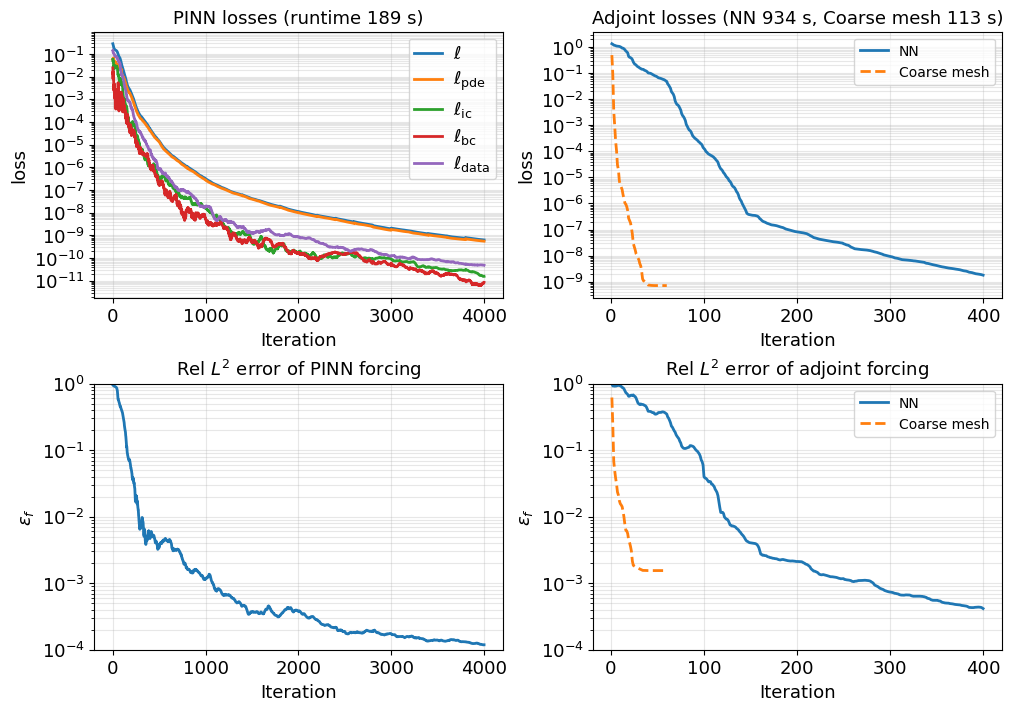

In [13]:
# Load saved results
adj_data = np.load(cfg.adj_nn_path, allow_pickle=True)
pinn_data = np.load(cfg.pinn_scipy_path, allow_pickle=True)

from matplotlib.ticker import LogLocator, LogFormatterMathtext

runtime_pinn = float(pinn_data['runtime_sec'])
runtime_adj_nn = float(adj_data['runtime_sec'])
runtime_adj_pc = float(t1_c - t0_c)

iter_loss_nn = np.asarray(adj_data['iter_loss'] if len(adj_data['iter_loss']) > 0 else adj_data['eval_loss'], dtype=float)
iter_rf_nn = np.asarray(adj_data['iter_rel_l2_f'] if len(adj_data['iter_rel_l2_f']) > 0 else adj_data['eval_rel_l2_f'], dtype=float)

iters_c = coarse_history['iters']
evals_c = coarse_history['evals']
iter_loss_pc = np.asarray([row['loss'] for row in (iters_c if len(iters_c) > 0 else evals_c)], dtype=float)
iter_rf_pc = np.asarray([row['rel_f'] for row in (iters_c if len(iters_c) > 0 else evals_c)], dtype=float)

pinn_iter_axis = np.arange(1, len(pinn_data['bfgs_loss']) + 1)
adj_nn_axis = np.arange(1, len(iter_loss_nn) + 1)
adj_pc_axis = np.arange(1, len(iter_loss_pc) + 1)

fig, axes = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)
axes = axes.ravel()
axes[0].semilogy(pinn_iter_axis, pinn_data['bfgs_loss'] + 1.0e-30, lw=2, label=r'$\ell$')
axes[0].semilogy(pinn_iter_axis, pinn_data['bfgs_L_res'] + 1.0e-30, lw=2, label=r'$\ell_{\mathrm{pde}}$')
axes[0].semilogy(pinn_iter_axis, pinn_data['bfgs_L_ic'] + 1.0e-30, lw=2, label=r'$\ell_{\mathrm{ic}}$')
axes[0].semilogy(pinn_iter_axis, pinn_data['bfgs_L_bc'] + 1.0e-30, lw=2, label=r'$\ell_{\mathrm{bc}}$')
axes[0].semilogy(pinn_iter_axis, pinn_data['bfgs_L_data'] + 1.0e-30, lw=2, label=r'$\ell_{\mathrm{data}}$')
axes[0].set_title(f'PINN losses (runtime {runtime_pinn:.0f} s)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('loss')
axes[0].yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=100))
axes[0].yaxis.set_major_formatter(LogFormatterMathtext(base=10.0))
axes[0].yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
axes[0].legend()

axes[1].semilogy(adj_nn_axis, iter_loss_nn + 1.0e-30, lw=2, label='NN')
axes[1].semilogy(adj_pc_axis, iter_loss_pc + 1.0e-30, '--', lw=2, label='Coarse mesh')
axes[1].set_title(f'Adjoint losses (NN {runtime_adj_nn:.0f} s, Coarse mesh {runtime_adj_pc:.0f} s)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('loss')
axes[1].set_yscale('log')
axes[1].yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=100))
axes[1].yaxis.set_major_formatter(LogFormatterMathtext(base=10.0))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1, numticks=100))
axes[1].legend()

axes[2].semilogy(pinn_iter_axis, pinn_data['bfgs_rel_l2_f'] + 1.0e-30, lw=2)
axes[2].set_title(r'Rel $L^2$ error of PINN forcing')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel(r'$\varepsilon_f$')

axes[3].semilogy(adj_nn_axis, iter_rf_nn + 1.0e-30, lw=2, label='NN')
axes[3].semilogy(adj_pc_axis, iter_rf_pc + 1.0e-30, '--', lw=2, label='Coarse mesh')
axes[3].set_title(r'Rel $L^2$ error of adjoint forcing')
axes[3].set_xlabel('Iteration')
axes[3].set_ylabel(r'$\varepsilon_f$')
axes[3].legend()

force_histories = [
    np.asarray(pinn_data['bfgs_rel_l2_f'], dtype=float),
    np.asarray(iter_rf_nn, dtype=float),
    np.asarray(iter_rf_pc, dtype=float),
]
positive_chunks = [hist[hist > 0.0] for hist in force_histories if np.any(hist > 0.0)]
if positive_chunks:
    force_positive = np.concatenate(positive_chunks)
    force_ymin = 10.0 ** np.floor(np.log10(force_positive.min()))
    force_ymax = 10.0 ** np.ceil(np.log10(force_positive.max()))
    axes[2].set_ylim(force_ymin, force_ymax)
    axes[3].set_ylim(force_ymin, force_ymax)

for ax in axes:
    ax.grid(True, which='both', alpha=0.3)
    ax.set_title(ax.get_title(), fontsize=13)
    ax.set_xlabel(ax.get_xlabel(), fontsize=13)
    ax.set_ylabel(ax.get_ylabel(), fontsize=13)
    ax.tick_params(axis='both', which='both', labelsize=13)

legend = axes[0].get_legend()
if legend is not None:
    for text in legend.get_texts():
        text.set_fontsize(13)

fig.savefig('figures/training_history.png', bbox_inches='tight', dpi=300)
plt.show()

### 7.2 Learned Force $s(x)$

Force errors — Adjoint NN: 4.1571e-04, PINN: 1.1875e-04, Coarse mesh ($N_f$=64): 1.5494e-03


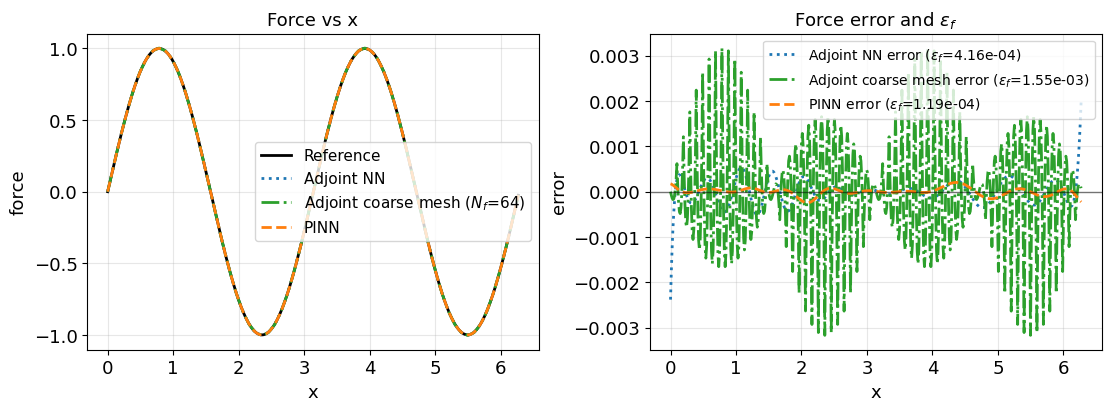

In [14]:
from PINN import MLP, load_models
from adjoint_operator import nn_force_forward

# --- Adjoint NN force ---
phi_opt = adj_data['phi_opt']
x_eval = core.x
s_adj, _ = nn_force_forward(x_eval, phi_opt, cfg)
s_true_eval = true_force(x_eval)

# --- PINN force ---
device = cfg.device
U_pinn = MLP(2, 1, cfg.hidden_U, cfg.layers_U, cfg.act_U).to(device).double()
S_pinn = MLP(1, 1, cfg.hidden_S, cfg.layers_S, cfg.act_S).to(device).double()
load_models(cfg, U_pinn, S_pinn, cfg.pinn_scipy_model)

with torch.no_grad():
    x_t = torch.tensor(x_eval, dtype=torch.float64, device=device).view(-1, 1)
    s_pinn = S_pinn(x_t).cpu().numpy().ravel()

# --- Coarse PC force (interpolated to fine grid) ---
s_pc_fine = s_opt_fine

err_adj = rel_l2_error(s_adj, s_true_eval)
err_pinn = rel_l2_error(s_pinn, s_true_eval)
err_pc = rel_l2_error(s_pc_fine, s_true_eval)
print(rf"Force errors — Adjoint NN: {err_adj:.4e}, PINN: {err_pinn:.4e}, Coarse mesh ($N_f$=64): {err_pc:.4e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

axes[0].plot(x_eval, s_true_eval, color='k', lw=2, label='Reference')
axes[0].plot(x_eval, s_adj, ':', color='C0', lw=2, label='Adjoint NN')
axes[0].plot(x_eval, s_pc_fine, '-.', color='C2', lw=2, label=r'Adjoint coarse mesh ($N_f$=64)')
axes[0].plot(x_eval, s_pinn, '--', color='C1', lw=2, label='PINN')
axes[0].set_title('Force vs x', fontsize=13)
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel('force', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_eval, s_adj - s_true_eval, ':', color='C0', lw=2, label=fr'Adjoint NN error ($\varepsilon_f$={err_adj:.2e})')
axes[1].plot(x_eval, s_pc_fine - s_true_eval, '-.', color='C2', lw=2, label=fr'Adjoint coarse mesh error ($\varepsilon_f$={err_pc:.2e})')
axes[1].plot(x_eval, s_pinn - s_true_eval, '--', color='C1', lw=2, label=fr'PINN error ($\varepsilon_f$={err_pinn:.2e})')
axes[1].axhline(0.0, color='k', lw=1, alpha=0.5)
axes[1].set_title(r'Force error and $\varepsilon_f$', fontsize=13)
axes[1].set_xlabel('x', fontsize=13)
axes[1].set_ylabel('error', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis='both', which='both', labelsize=13)

fig.savefig('figures/learned_force.png', bbox_inches='tight', dpi=300)
plt.show()

### 7.3 Terminal Solution $u(x, T)$

uT errors — Adjoint NN: 2.8609e-05, Coarse mesh: 1.8050e-05, PINN: 5.7168e-05


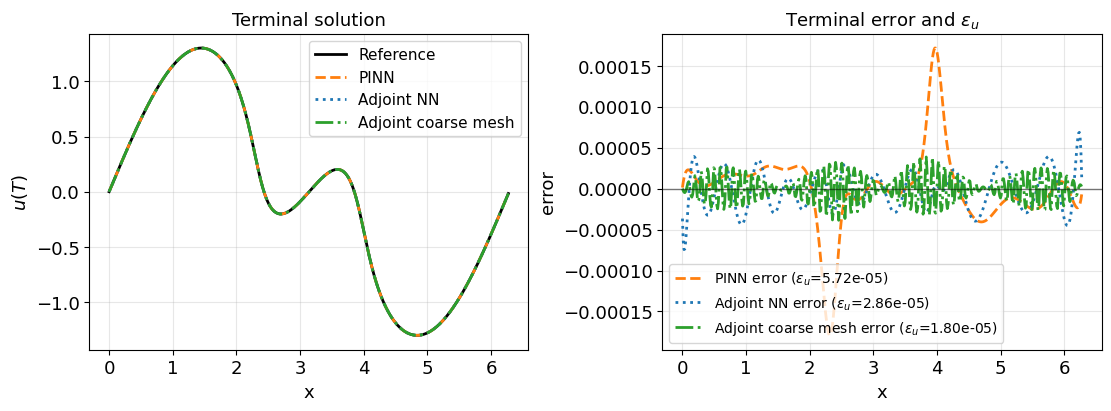

In [19]:
from adjoint_operator import simulate_with_phi

# --- Adjoint NN: re-simulate with learned phi ---
uT_adj, _, _, _ = simulate_with_phi(cfg, u0, phi_opt)

# --- Adjoint Coarse mesh: simulate CN with coarse force (interpolated) ---
uT_pc = burgers_forward(u0, s_opt_fine, cfg)['u_final']

# --- PINN: simulate CN with PINN's learned S(x) ---
with torch.no_grad():
    x_t = torch.tensor(x, dtype=torch.float64, device=device).view(-1, 1)
    s_pinn_grid = S_pinn(x_t).cpu().numpy().ravel()
uT_pinn = burgers_forward(u0, s_pinn_grid, cfg)['u_final']

err_adj_uT = rel_l2_error(uT_adj, uT_target)
err_pc_uT = rel_l2_error(uT_pc, uT_target)
err_pinn_uT = rel_l2_error(uT_pinn, uT_target)
print(rf"uT errors — Adjoint NN: {err_adj_uT:.4e}, Coarse mesh: {err_pc_uT:.4e}, PINN: {err_pinn_uT:.4e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

axes[0].plot(x, uT_target, color='k', lw=2, label='Reference')
axes[0].plot(x, uT_pinn, '--', color='C1', lw=2, label='PINN')
axes[0].plot(x, uT_adj, ':', color='C0', lw=2, label='Adjoint NN')
axes[0].plot(x, uT_pc, '-.', color='C2', lw=2, label=r'Adjoint coarse mesh')
axes[0].set_title('Terminal solution', fontsize=13)
axes[0].set_xlabel('x', fontsize=13)
axes[0].set_ylabel(r'$u(T)$', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, uT_pinn - uT_target, '--', color='C1', lw=2, label=fr'PINN error ($\varepsilon_u$={err_pinn_uT:.2e})')
axes[1].plot(x, uT_adj - uT_target, ':', color='C0', lw=2, label=fr'Adjoint NN error ($\varepsilon_u$={err_adj_uT:.2e})')
axes[1].plot(x, uT_pc - uT_target, '-.', color='C2', lw=2, label=fr'Adjoint coarse mesh error ($\varepsilon_u$={err_pc_uT:.2e})')
axes[1].axhline(0.0, color='k', lw=1, alpha=0.5)
axes[1].set_title(r'Terminal error and $\varepsilon_u$', fontsize=13)
axes[1].set_xlabel('x', fontsize=13)
axes[1].set_ylabel('error', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.tick_params(axis='both', which='both', labelsize=13)

fig.savefig('figures/terminal_solution.png', bbox_inches='tight', dpi=300)
plt.show()